In [1]:
# IPL DATA ANALYSIS PROJECT
# Data Analytics Master Program

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("IPL DATA ANALYSIS PROJECT")
print("=" * 50)

IPL DATA ANALYSIS PROJECT


In [2]:
# Load IPL datasets

matches = pd.read_csv("../Dataset/IPL_Cleaned_Matches.csv")
deliveries = pd.read_csv("../Dataset/IPL_Cleaned_Deliveries.csv")
season_summary = pd.read_csv("../Dataset/IPL_Season_Summary.csv")

print("Datasets loaded successfully!")
print("-" * 50)

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print("Season Summary shape:", season_summary.shape)

Datasets loaded successfully!
--------------------------------------------------
Matches shape: (1095, 22)
Deliveries shape: (260920, 17)
Season Summary shape: (17, 3)


In [3]:
# Data Exploration

print("MATCHES DATASET")
print("=" * 50)
print(matches.head())

print("\nMATCHES INFORMATION")
print("=" * 50)
print(matches.info())

print("\nDELIVERIES DATASET")
print("=" * 50)
print(deliveries.head())

print("\nSEASON SUMMARY")
print("=" * 50)
print(season_summary)

MATCHES DATASET
       id  season        city        date match_type player_of_match  \
0  335982    2008   Bangalore  2008-04-18     League     BB McCullum   
1  335983    2008  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984    2008       Delhi  2008-04-19     League     MF Maharoof   
3  335985    2008      Mumbai  2008-04-20     League      MV Boucher   
4  335986    2008     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bengaluru   
1  Punjab Cricket Association Stadium, Mohali                 Punjab Kings   
2                            Feroz Shah Kotla               Delhi Capitals   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0    

In [4]:
# Data Cleaning and Missing Value Check

print("Missing values in Matches:")
print(matches.isnull().sum())

print("\nMissing values in Deliveries:")
print(deliveries.isnull().sum())

print("\nDuplicate rows:")
print("Matches:", matches.duplicated().sum())
print("Deliveries:", deliveries.duplicated().sum())

print("\nData types in Matches:")
print(matches.dtypes)

Missing values in Matches:
id                      0
season                  0
city                   51
date                    0
match_type              0
player_of_match         5
venue                   0
team1                   0
team2                   0
toss_winner             0
toss_decision           0
winner                  5
result                  0
result_margin          19
target_runs             3
target_overs            3
super_over              0
method               1074
umpire1                 0
umpire2                 0
toss_match_winner       0
win_margin_type         0
dtype: int64

Missing values in Deliveries:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wic

In [5]:
# Basic Match Analysis

print("Total Matches:", matches["id"].nunique())

print("\nSeasons Covered:")
print(sorted(matches["season"].unique()))

print("\nMatches by Season:")
matches_per_season = matches.groupby("season")["id"].nunique()
print(matches_per_season)

print("\nTop Winning Teams:")
team_wins = matches["winner"].value_counts()
print(team_wins.head(10))

Total Matches: 1095

Seasons Covered:
[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Matches by Season:
season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
Name: id, dtype: int64

Top Winning Teams:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Punjab Kings                   112
Rajasthan Royals               112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Name: count, dtype: int64


In [6]:
# Player Performance Analysis

# Top 10 batsmen by total runs
top_batsmen = (
    deliveries.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Batsmen by Total Runs:")
print(top_batsmen)

# Top 10 bowlers by wickets
top_bowlers = (
    deliveries[deliveries["is_wicket"] == 1]
    .groupby("bowler")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Bowlers by Wickets:")
print(top_bowlers)

# Top 10 players by Player of the Match awards
top_players = (
    matches["player_of_match"]
    .value_counts()
    .head(10)
)

print("\nTop 10 Player of the Match Awards:")
print(top_players)

Top 10 Batsmen by Total Runs:
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

Top 10 Bowlers by Wickets:
bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
dtype: int64

Top 10 Player of the Match Awards:
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
AD Russell        15
Name: count, dtype: int64


In [7]:
# Team Performance Analysis

print("Matches Won by Each Team:")
team_wins = matches["winner"].value_counts()
print(team_wins)

print("\nRuns Scored by Each Team:")

team_runs = (
    deliveries.groupby("batting_team")["total_runs"]
    .sum()
    .sort_values(ascending=False)
)

print(team_runs)

Matches Won by Each Team:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Punjab Kings                   112
Rajasthan Royals               112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

Runs Scored by Each Team:
batting_team
Mumbai Indians                 42176
Royal Challengers Bengaluru    40622
Punjab Kings                   39600
Kolkata Knight Riders          39331
Delhi Capitals                 39196
Chennai Super Kings            38629
Rajasthan Royals               34747
Sunrisers Hyderabad            29071
Deccan Chargers                11463
Gujarat Titans                  7757
Luckno

In [8]:
# Toss Analysis

print("Toss Decisions:")
toss_decisions = matches["toss_decision"].value_counts()
print(toss_decisions)

print("\nToss Winners:")
toss_winners = matches["toss_winner"].value_counts().head(10)
print(toss_winners)

# Check how often the toss winner also won the match
toss_match_wins = (matches["toss_winner"] == matches["winner"]).sum()
total_completed_matches = matches["winner"].notna().sum()

print("\nToss Winner Also Won Match:")
print(f"{toss_match_wins} out of {total_completed_matches}")

print(
    "Percentage:",
    round((toss_match_wins / total_completed_matches) * 100, 2),
    "%"
)

Toss Decisions:
toss_decision
field    704
bat      391
Name: count, dtype: int64

Toss Winners:
toss_winner
Mumbai Indians                 143
Delhi Capitals                 130
Kolkata Knight Riders          122
Chennai Super Kings            122
Royal Challengers Bengaluru    121
Rajasthan Royals               120
Punjab Kings                   109
Sunrisers Hyderabad             88
Deccan Chargers                 43
Gujarat Titans                  22
Name: count, dtype: int64

Toss Winner Also Won Match:
554 out of 1090
Percentage: 50.83 %


In [10]:
# Season-wise Analysis

# Add season information to deliveries using match ID
deliveries_with_season = deliveries.merge(
    matches[["id", "season"]],
    left_on="match_id",
    right_on="id",
    how="left"
)

# Total runs by season
season_runs = (
    deliveries_with_season
    .groupby("season")["total_runs"]
    .sum()
)

# Total wickets by season
season_wickets = (
    deliveries_with_season[deliveries_with_season["is_wicket"] == 1]
    .groupby("season")
    .size()
)

print("Total Runs by Season:")
print(season_runs)

print("\nTotal Wickets by Season:")
print(season_wickets)

Total Runs by Season:
season
2008    17937
2009    16353
2010    18883
2011    21154
2012    22453
2013    22602
2014    18931
2015    18353
2016    18862
2017    18786
2018    19901
2019    19434
2020    19416
2021    18637
2022    24395
2023    25688
2024    25971
Name: total_runs, dtype: int64

Total Wickets by Season:
season
2008    690
2009    698
2010    725
2011    813
2012    858
2013    912
2014    674
2015    691
2016    666
2017    711
2018    722
2019    685
2020    677
2021    717
2022    912
2023    916
2024    883
dtype: int64


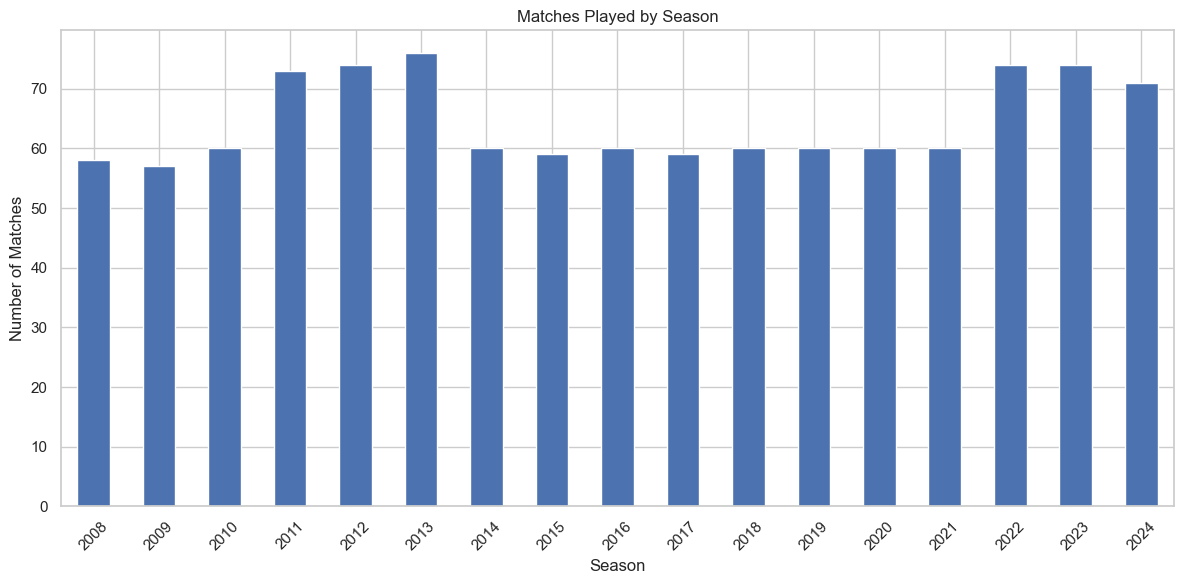

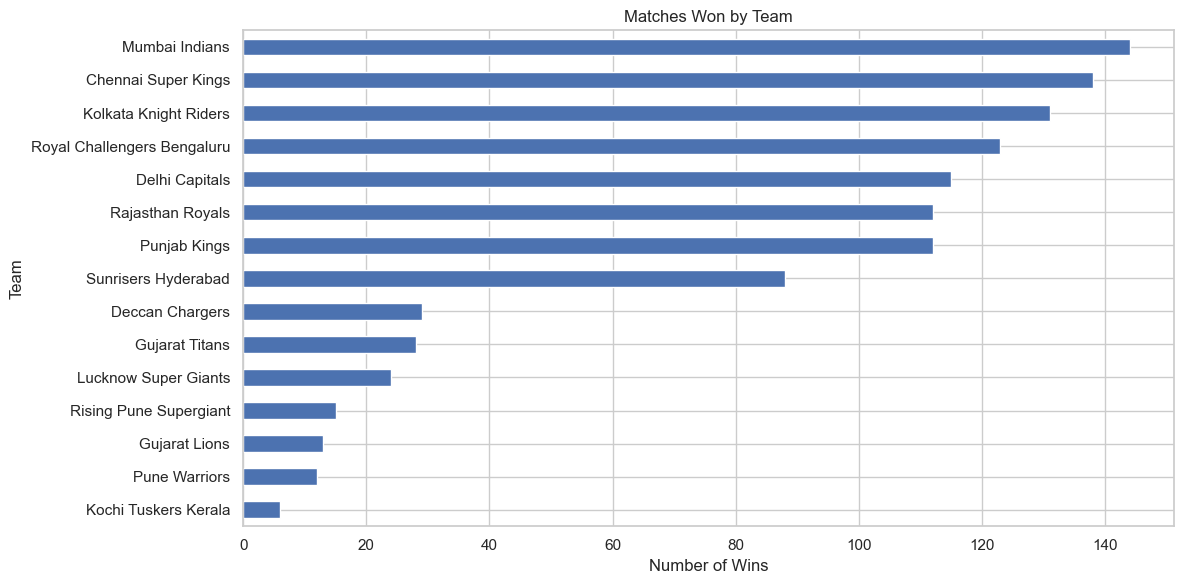

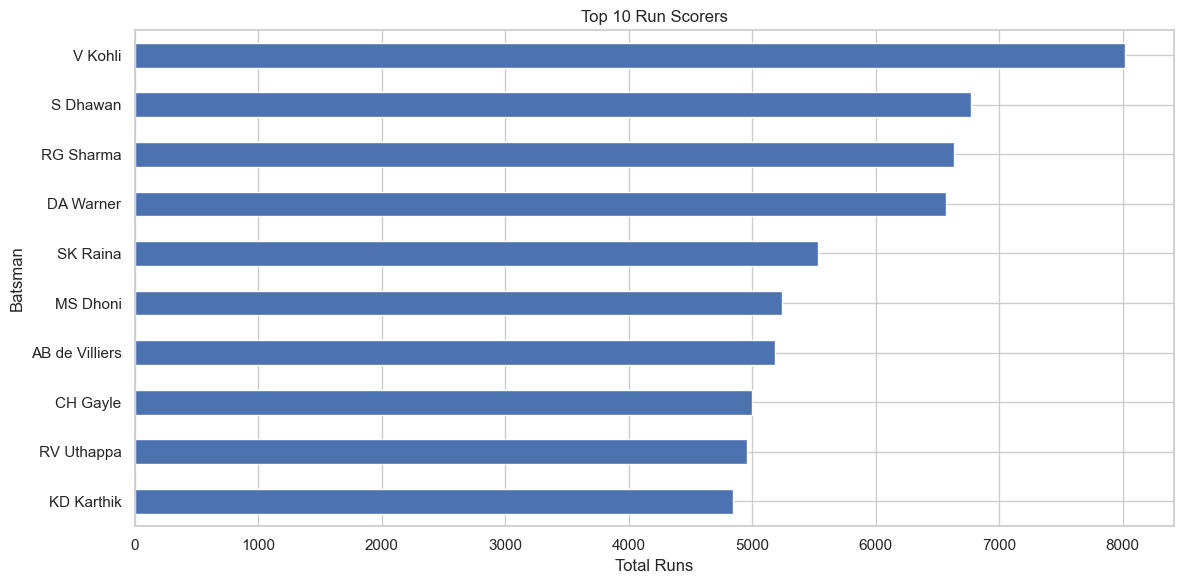

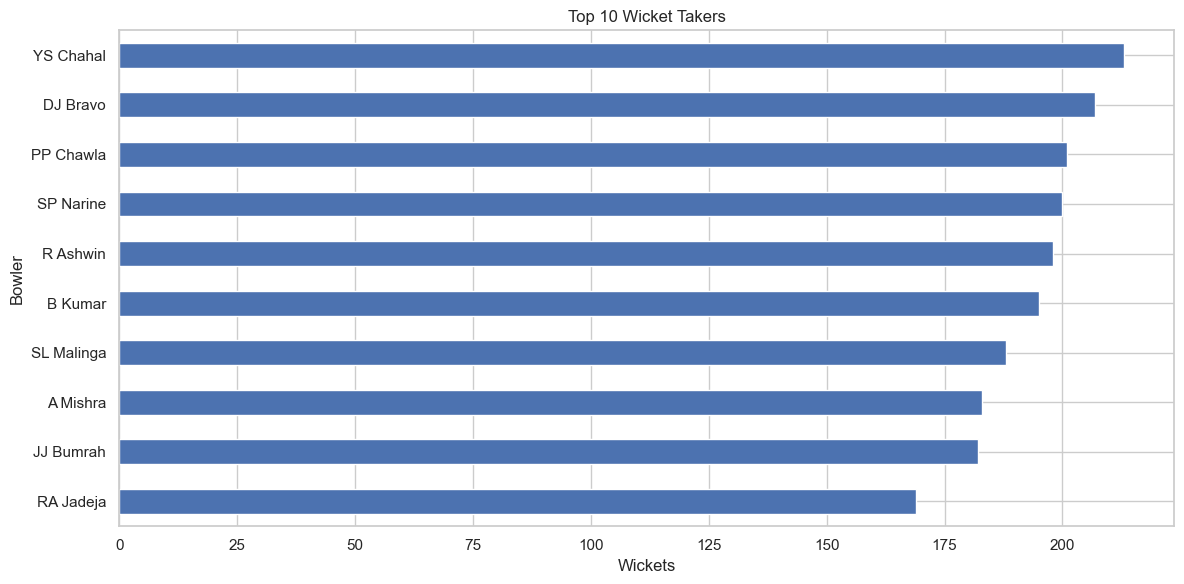

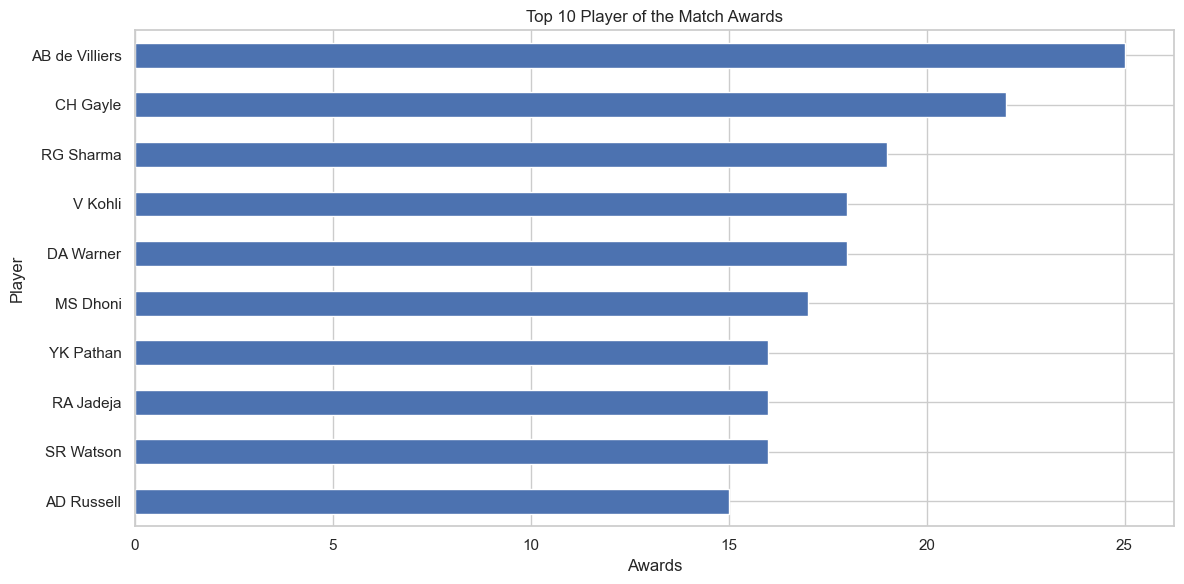

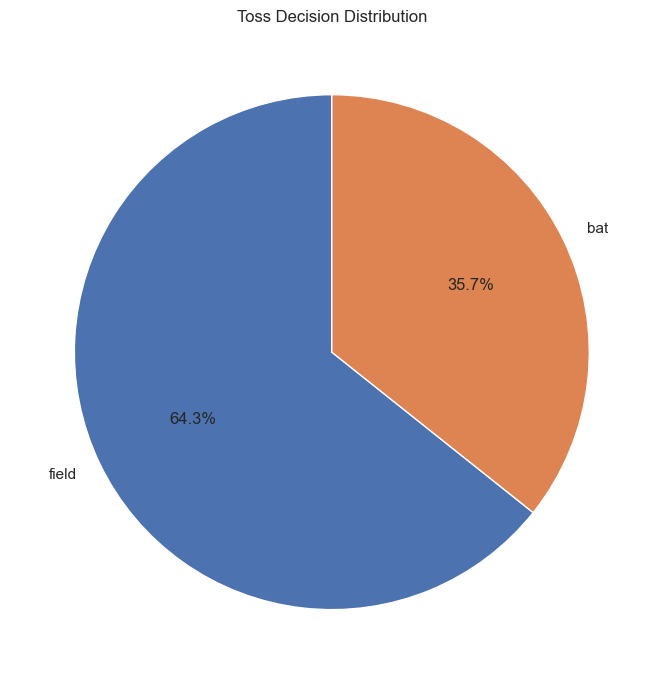

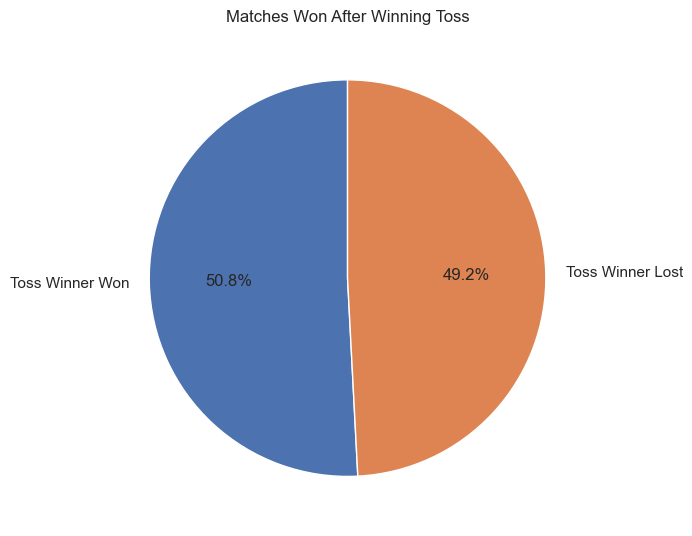

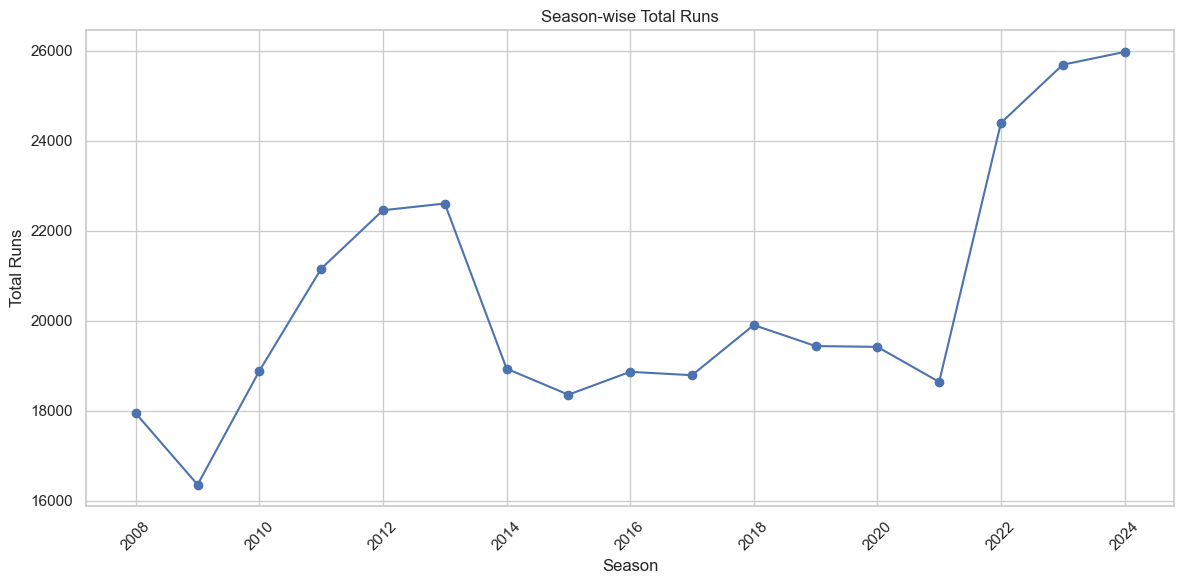

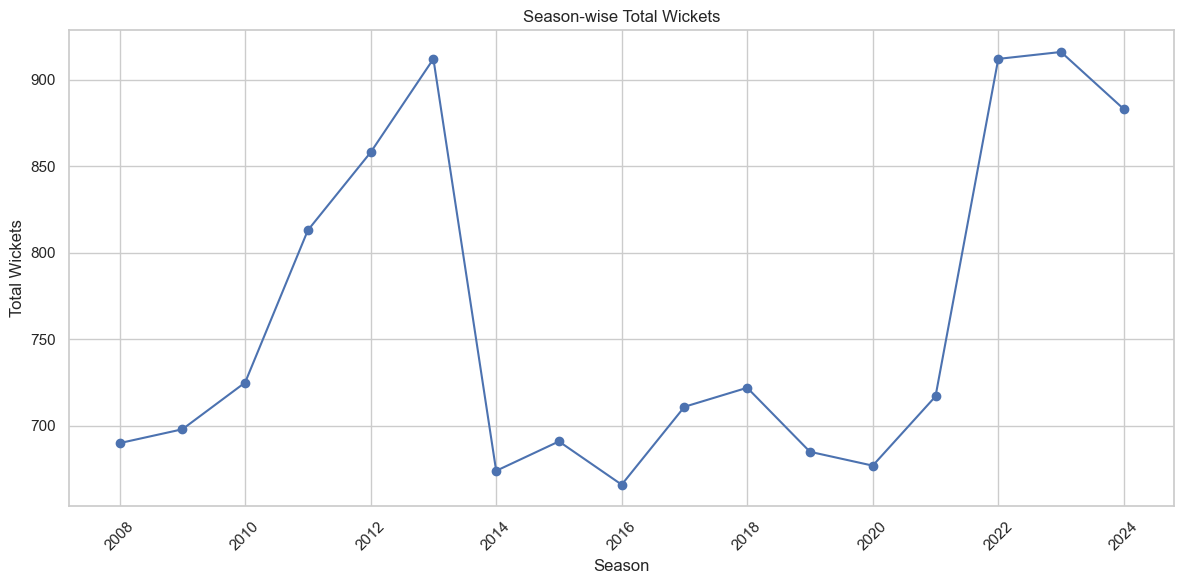

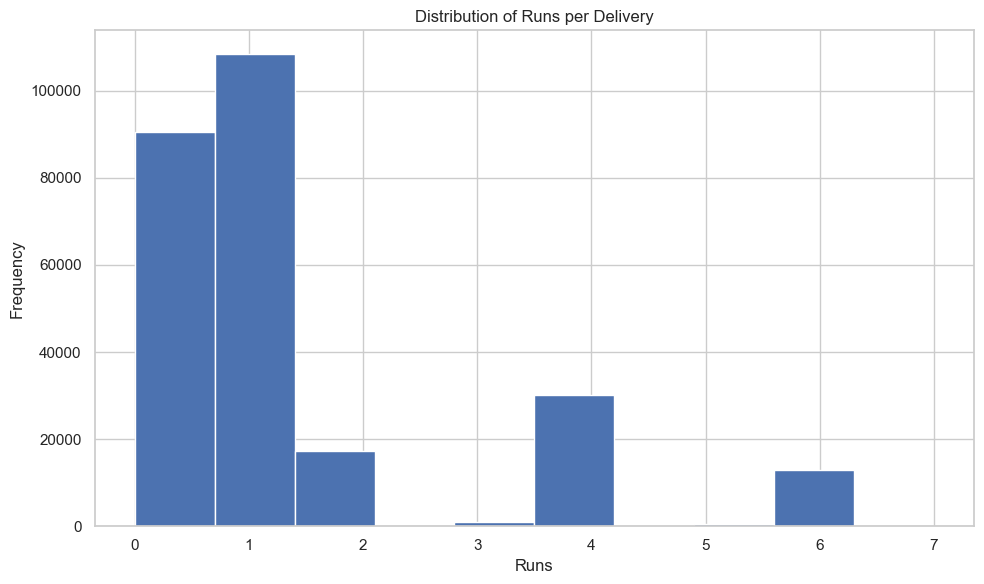

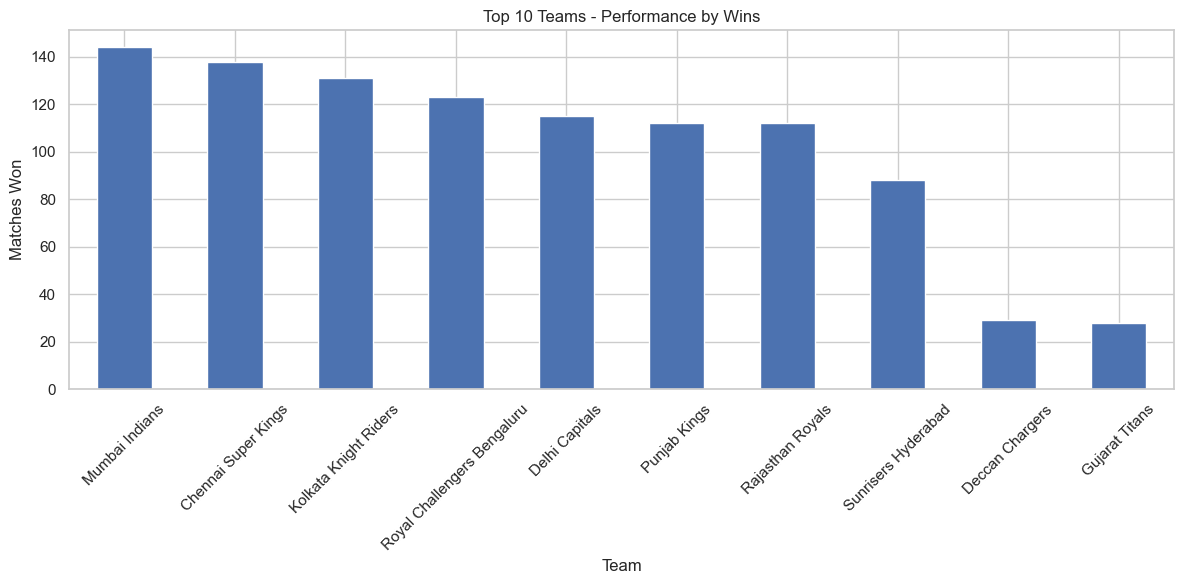

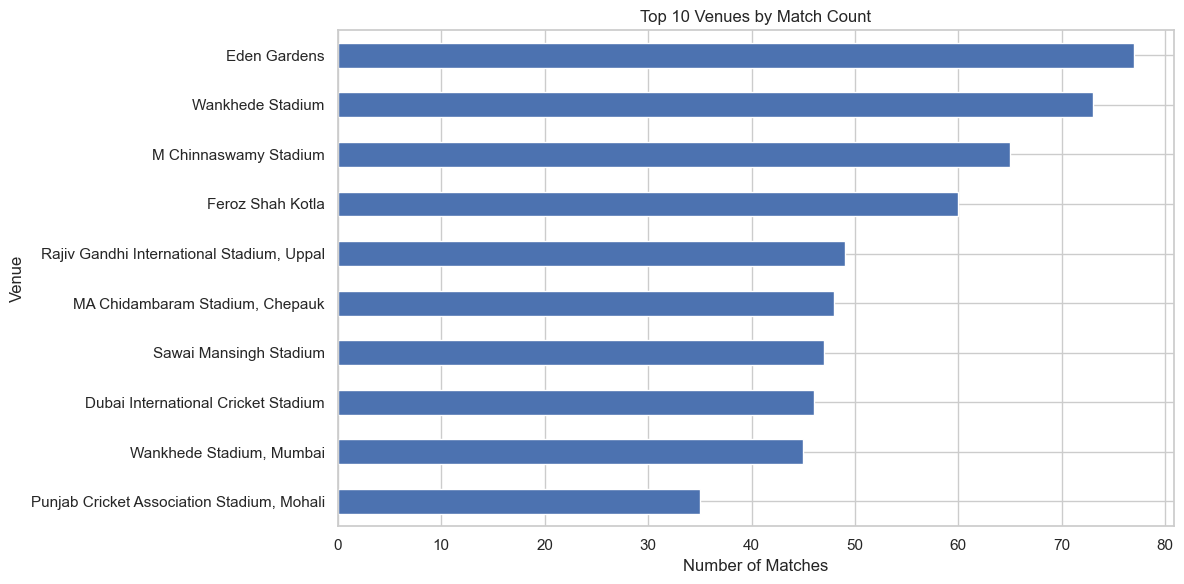

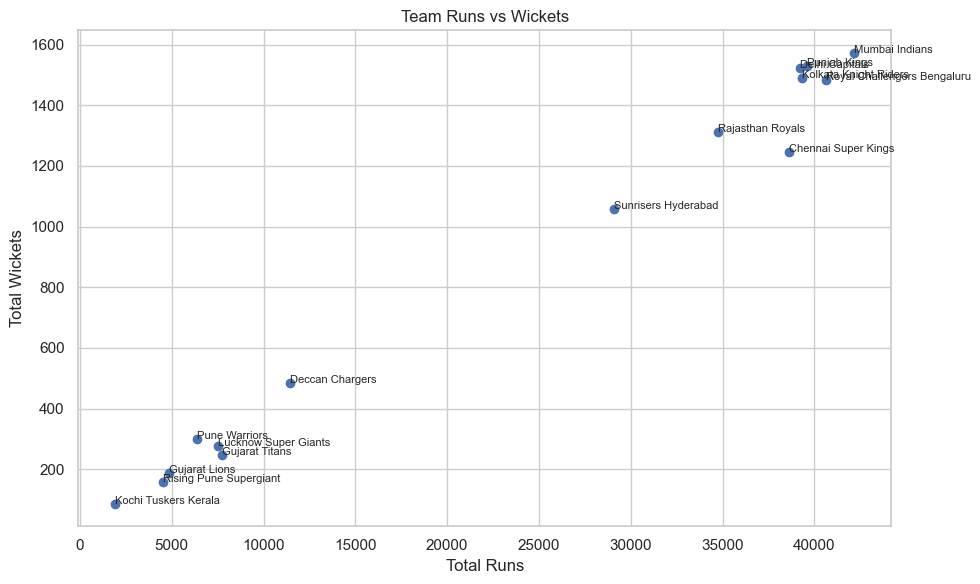

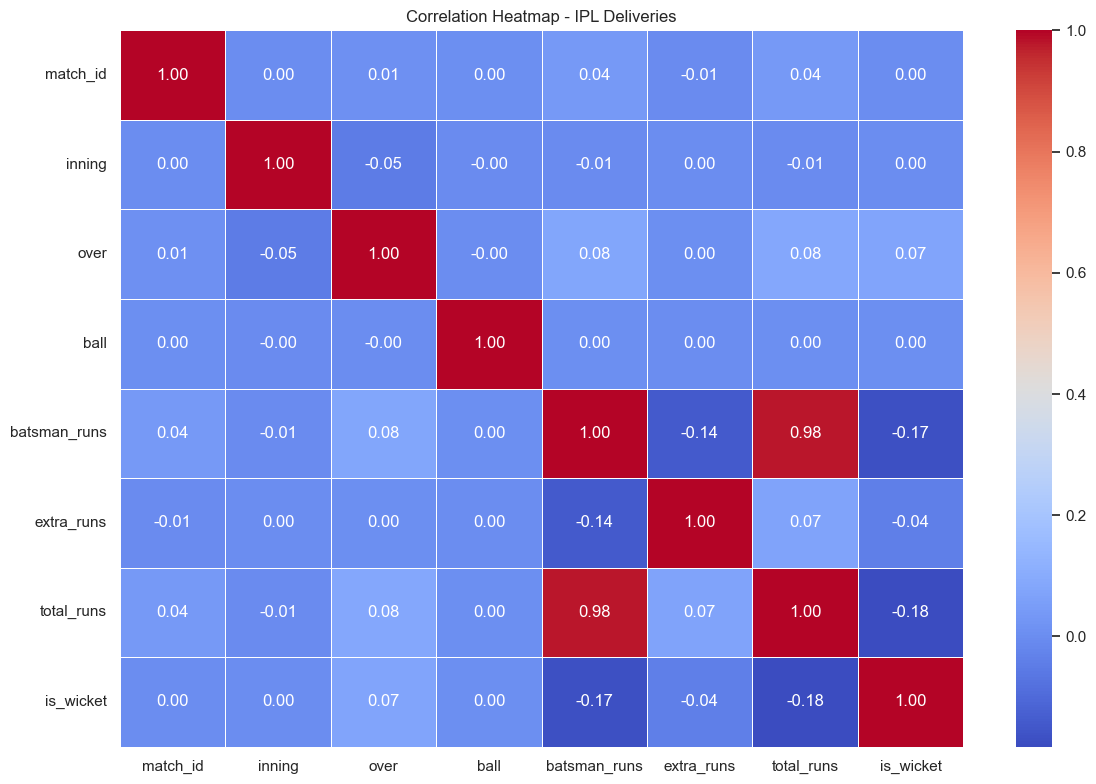

ALL 14 IPL VISUALIZATIONS CREATED SUCCESSFULLY


In [12]:
# ============================================================
# IPL DATA ANALYSIS - PYTHON VISUALIZATIONS
# ============================================================

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# Chart 1: Matches Played by Season
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
matches_per_season.plot(kind="bar")
plt.title("Matches Played by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 2: Matches Won by Team
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
team_wins.sort_values().plot(kind="barh")
plt.title("Matches Won by Team")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 3: Top 10 Run Scorers
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
top_batsmen.sort_values().plot(kind="barh")
plt.title("Top 10 Run Scorers")
plt.xlabel("Total Runs")
plt.ylabel("Batsman")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 4: Top 10 Wicket Takers
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
top_bowlers.sort_values().plot(kind="barh")
plt.title("Top 10 Wicket Takers")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 5: Player of the Match Awards
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
top_players.sort_values().plot(kind="barh")
plt.title("Top 10 Player of the Match Awards")
plt.xlabel("Awards")
plt.ylabel("Player")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 6: Toss Decision Distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))
toss_decisions.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Toss Decision Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 7: Matches Won After Winning Toss
# ------------------------------------------------------------

toss_result = pd.Series({
    "Toss Winner Won": toss_match_wins,
    "Toss Winner Lost": total_completed_matches - toss_match_wins
})

plt.figure(figsize=(7, 7))
toss_result.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Matches Won After Winning Toss")
plt.ylabel("")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 8: Season-wise Total Runs
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
season_runs.plot(kind="line", marker="o")
plt.title("Season-wise Total Runs")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 9: Season-wise Total Wickets
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
season_wickets.plot(kind="line", marker="o")
plt.title("Season-wise Total Wickets")
plt.xlabel("Season")
plt.ylabel("Total Wickets")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 10: Runs Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
deliveries["total_runs"].plot(kind="hist", bins=10)
plt.title("Distribution of Runs per Delivery")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 11: Team Performance Comparison
# ------------------------------------------------------------

team_performance = pd.DataFrame({
    "Wins": team_wins,
    "Runs": team_runs
}).fillna(0)

team_performance = team_performance.sort_values("Wins", ascending=False).head(10)

plt.figure(figsize=(12, 6))
team_performance["Wins"].plot(kind="bar")
plt.title("Top 10 Teams - Performance by Wins")
plt.xlabel("Team")
plt.ylabel("Matches Won")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 12: Venue-wise Match Count
# ------------------------------------------------------------

venue_matches = matches["venue"].value_counts().head(10)

plt.figure(figsize=(12, 6))
venue_matches.sort_values().plot(kind="barh")
plt.title("Top 10 Venues by Match Count")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 13: Runs vs Wickets
# ------------------------------------------------------------

team_wicket_data = (
    deliveries[deliveries["is_wicket"] == 1]
    .groupby("batting_team")
    .size()
    .rename("Wickets")
)

runs_wicket = pd.DataFrame({
    "Runs": team_runs,
    "Wickets": team_wicket_data
}).dropna()

plt.figure(figsize=(10, 6))
plt.scatter(
    runs_wicket["Runs"],
    runs_wicket["Wickets"]
)

for team, row in runs_wicket.iterrows():
    plt.annotate(
        team,
        (row["Runs"], row["Wickets"]),
        fontsize=8
    )

plt.title("Team Runs vs Wickets")
plt.xlabel("Total Runs")
plt.ylabel("Total Wickets")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 14: Correlation Heatmap
# ------------------------------------------------------------

numeric_columns = deliveries.select_dtypes(
    include=np.number
).columns

correlation = deliveries[numeric_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap - IPL Deliveries")
plt.tight_layout()
plt.show()


print("=" * 60)
print("ALL 14 IPL VISUALIZATIONS CREATED SUCCESSFULLY")
print("=" * 60)

In [13]:
# ============================================================
# BUSINESS INSIGHTS
# ============================================================

print("IPL DATA ANALYSIS - BUSINESS INSIGHTS")
print("=" * 60)

print("\n1. Team Performance")
print("Team wins were analyzed to identify the strongest performing teams.")

print("\n2. Player Performance")
print("Top batsmen were identified based on total runs scored.")
print("Top bowlers were identified based on total wickets taken.")

print("\n3. Toss Impact")
print(
    f"Toss winners also won {toss_match_wins} "
    f"out of {total_completed_matches} completed matches, "
    f"representing {round((toss_match_wins / total_completed_matches) * 100, 2)}%."
)

print("\n4. Season Trends")
print("Season-wise runs and wickets were analyzed to understand IPL trends.")

print("\n5. Venue Analysis")
print("Venue-wise match counts were analyzed to identify frequently used venues.")

print("\n6. Overall Insight")
print(
    "The analysis demonstrates how IPL match, player, team, toss, "
    "season and venue data can be used to generate meaningful "
    "sports analytics insights."
)

print("=" * 60)

IPL DATA ANALYSIS - BUSINESS INSIGHTS

1. Team Performance
Team wins were analyzed to identify the strongest performing teams.

2. Player Performance
Top batsmen were identified based on total runs scored.
Top bowlers were identified based on total wickets taken.

3. Toss Impact
Toss winners also won 554 out of 1090 completed matches, representing 50.83%.

4. Season Trends
Season-wise runs and wickets were analyzed to understand IPL trends.

5. Venue Analysis
Venue-wise match counts were analyzed to identify frequently used venues.

6. Overall Insight
The analysis demonstrates how IPL match, player, team, toss, season and venue data can be used to generate meaningful sports analytics insights.
